In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
import numpy as np
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


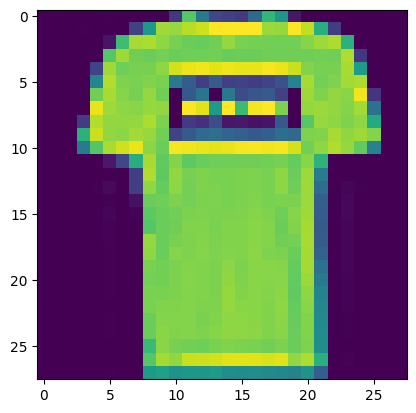

In [3]:
plt.imshow(x_train[1])

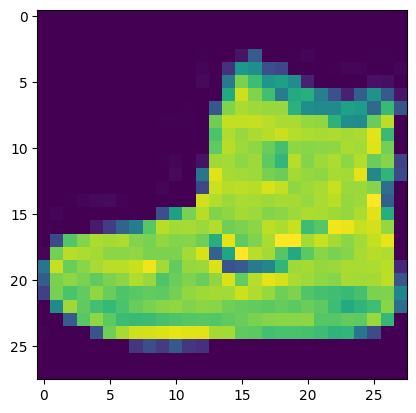

In [4]:
plt.imshow(x_train[0])

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [6]:
x_train.shape
(60000, 28, 28)
x_test.shape
(10000, 28, 28, 1)
y_train.shape
(60000,)
y_test.shape
(10000,)

(10000,)

In [8]:
model = keras.Sequential([
keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),keras.layers.MaxPooling2D((2,2)),keras.layers.Dropout(0.25),
                           keras.layers.Conv2D(64, (3,3), activation='relu'),keras.layers.MaxPooling2D((2,2)),keras.layers.Dropout(0.25),
keras.layers.Conv2D(128, (3,3), activation='relu'),keras.layers.Flatten(),
keras.layers.Dense(128, activation='relu'),keras.layers.Dropout(0.25),
keras.layers.Dense(10, activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 36ms/step - accuracy: 0.7847 - loss: 0.5705 - val_accuracy: 0.8582 - val_loss: 0.3894
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.8609 - loss: 0.3777 - val_accuracy: 0.8783 - val_loss: 0.3287
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 36ms/step - accuracy: 0.8799 - loss: 0.3273 - val_accuracy: 0.8821 - val_loss: 0.3167
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.8896 - loss: 0.2995 - val_accuracy: 0.9009 - val_loss: 0.2708
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 35ms/step - accuracy: 0.8966 - loss: 0.2809 - val_accuracy: 0.9012 - val_loss: 0.2738
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9006 - loss: 0.2654 - val_accuracy: 0.9020 - val_loss: 0.2676
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9051 - loss: 0.2553 - val_accuracy: 0.9046 - val_loss: 0.2598
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9060 -

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('Test accuracy:', test_acc)

313/313 - 4s - 12ms/step - accuracy: 0.9086 - loss: 0.2553
Test accuracy: 0.9085999727249146


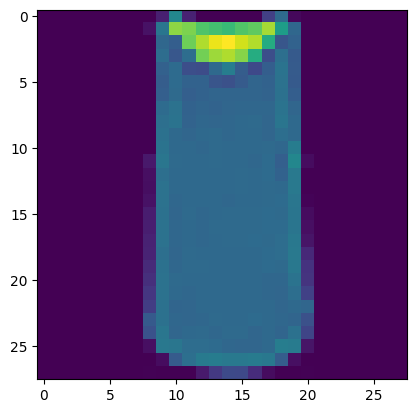

In [13]:
plt.imshow(x_train[2])

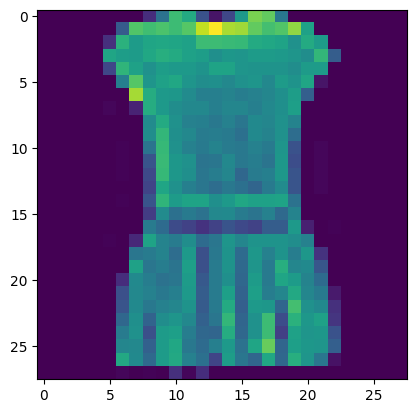

In [14]:
plt.imshow(x_train[3])

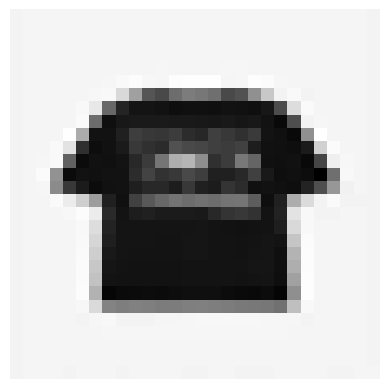

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: T-shirt/top
Confidence: 0.8163797


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# model already exists from above training

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

img_path = "/content/t_shirt2.jpg"

img = Image.open(img_path).convert('L')
img = img.resize((28, 28))

img_array = np.array(img)
img_array = img_array.astype('float32') / 255.0
img_array = img_array.reshape(1, 28, 28, 1)

plt.imshow(img_array[0].reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", np.max(prediction))

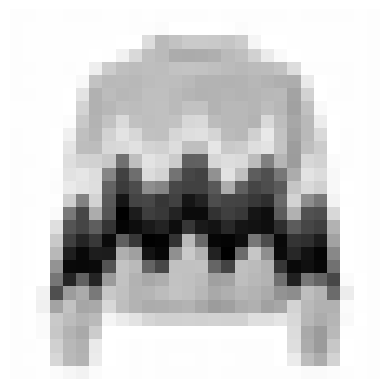

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Class: Pullover
Confidence: 0.6058423


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# model already exists from above training

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

img_path = "/content/pullover.jpg"

img = Image.open(img_path).convert('L')
img = img.resize((28, 28))

img_array = np.array(img)
img_array = img_array.astype('float32') / 255.0
img_array = img_array.reshape(1, 28, 28, 1)

plt.imshow(img_array[0].reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", np.max(prediction))

In [16]:
print(len(set(y_train)))

10


In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9086 - loss: 0.2553
Test Accuracy: 0.9085999727249146


In [17]:
import numpy as np
print(np.unique(y_train))
print(len(np.unique(y_train)))

[0 1 2 3 4 5 6 7 8 9]
10


In [18]:
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
